## Introduction

The Japan Meteorological Agency ([JMA](https://www.jma.go.jp/jma/index.html)) monitors and records various weather data including rainfall, wind speed and direction, temperature and relative humidity from over 840 sites across Japan through their Automated Meteorological Data Acquisition System (AMEDAS) [<sup>1</sup>](#references). Much of this data are publicly available online, and some datasets can be downloaded as CSV files. However, learning to scrape and parse weather data directly from their website with Python is useful because:

- Not all JMA datasets are available as CSV downloads
- Downloading hundreds of days of data from multiple weather stations manually can be painful

Data scraping allows you to retrieve any weather data available on the JMA website in a consistent and reproducible manner. Although it will require some time and effort upfront to write the code, once set up, the code can be easily modied to scrape data from different dates or weather stations.

In this tutorial, I'll walk through a method to scrape and parse 10-minute interval weather data of the Tokyo JMA weather station using Python libraries `requests` and `Beautiful Soup`. The tabular data will be cleaned and preprocessed with headers and wind directions translated from Japanese to English, and useful details will be attributed to the timestamps using `datetime` and `pytz` libraries.

### What You'll Learn in This Tutorial
By the end of this tutorial, you'll learn how to:

- **Scrape tabular weather data** from JMA's website using `requests` library
- **Parse and give structure** to the raw data with `Beautiful Soup` library
- **Clean and preprocess** the timestamps of the data with `datetime` and `pytz` libraries
- **Save** the data as a CSV file

If you prefer to skip the explanations and jump straight to the implementation, you can [download the code from my GitHub repository](https://github.com/MaiAndResearch/DataDrivenMai-blog/blob/main/JMA-weather-scraping/). 

Here are the list of things you'll need to run the code.



### Prerequisites
- `data/` subfolder for saving the CSV output
- Python libraries
    - `requests`
    - `bs4`
    - `datetime`
    - `pytz`
    - `pandas`

### Jargon

**Data scraping**: Using code to extract information from a web page or a source that's primarily designed for human viewing. In this blog post, we'll be pulling data from an HTML table on the JMA site.

**Data parsing**: Converting raw or unstructured text into something structured and easy to work with. For example, turning HTML table rows into a tidy `pandas` DataFrame.


## Scrape, Parse and Save Japan Weather Data

Here are the steps involved in collecting weather data from the JMA website:

1. Find the URL you want to retrieve data from
2. Use `requests` library to scrape all data on the web page
3. Use an HTML parser and `Beautiful Soup` library to give structure to the raw data
4. Navigate the HTML to extract just the desired data
5. Convert the desired data into a `pandas` DataFrame
6. Attribute useful details to the timestamps using `datetime` and `pytz` libraries
7. Save the DataFrame as a CSV file

Let's start with step 1.

### Step 1: Designate the URL with the Weather Data

First, we'll need the URL of the JMA webpage that contains the specific data we want to scrape. If you'd like to know the actual data scraping and parsing methods and do not care much for finding a specific JMA station, skip ahead to [step 2](#step-2). 

For those interested in finding your own JMA weather station, you can navigate the records of past weather data from [here](https://www.data.jma.go.jp/stats/etrn/index.php). Refer to @fig-findURL below to:

1. Narrow down on the JMA weather site by designating the prefecture (red box)
2. Pinpoint the observation site within the prefecture (orange box, activated once you designate the prefecture)
3. Choose the year, month and day for the desired data (green box)
4. Select the type of weather data to access (blue box)


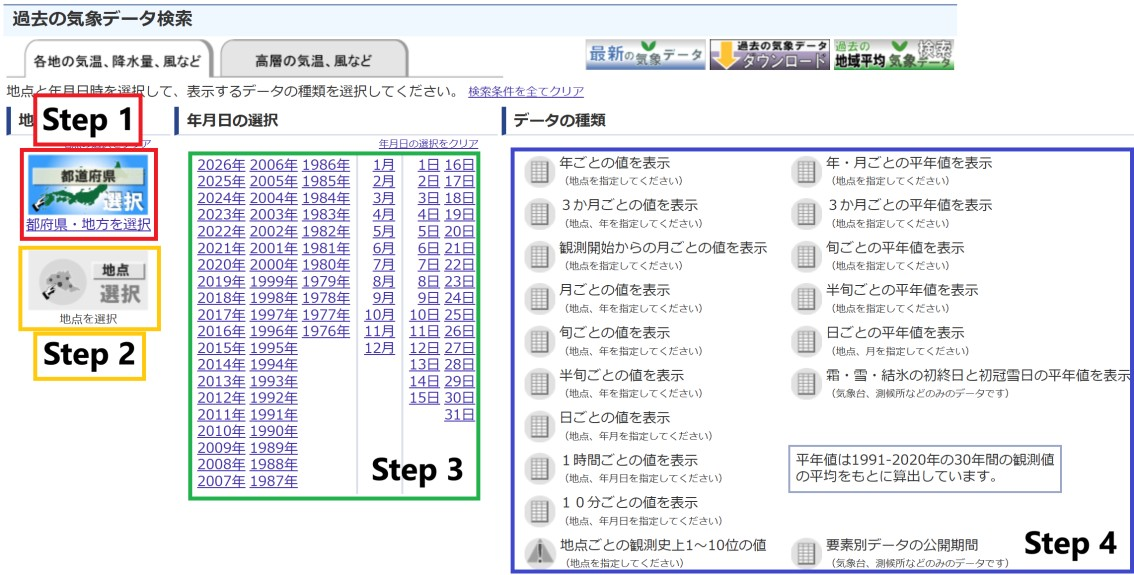{#fig-findURL}

You may need a combination of Google maps, a translation app and trial and error to navigate to your desired URL. You'll also notice that the column headers in the tables differ depending on the type of data you've selected from the blue box in @fig-findURL.

For the remainder of this blog post, we'll work with the 10-minute interval weather records. You can select the "１０分ごとの値" option located on the left column within the blue box, second from the bottom for a JMA observation site and date of your preference. I've provided a default test URL below, which accesses 10-minute interval weather records from the Tokyo site on March 9, 2024. 

In [13]:
# URL containing 10-minute interval weather data from Tokyo site on March 9, 2024
# Can be replaced with 10-minute data from any 's1' type observation site
testURL = 'https://www.data.jma.go.jp/stats/etrn/view/10min_s1.php?prec_no=44&block_no=47662&year=2024&month=3&day=9&view='

Accessing this URL, we find the tabular weather data which we will be scraping:

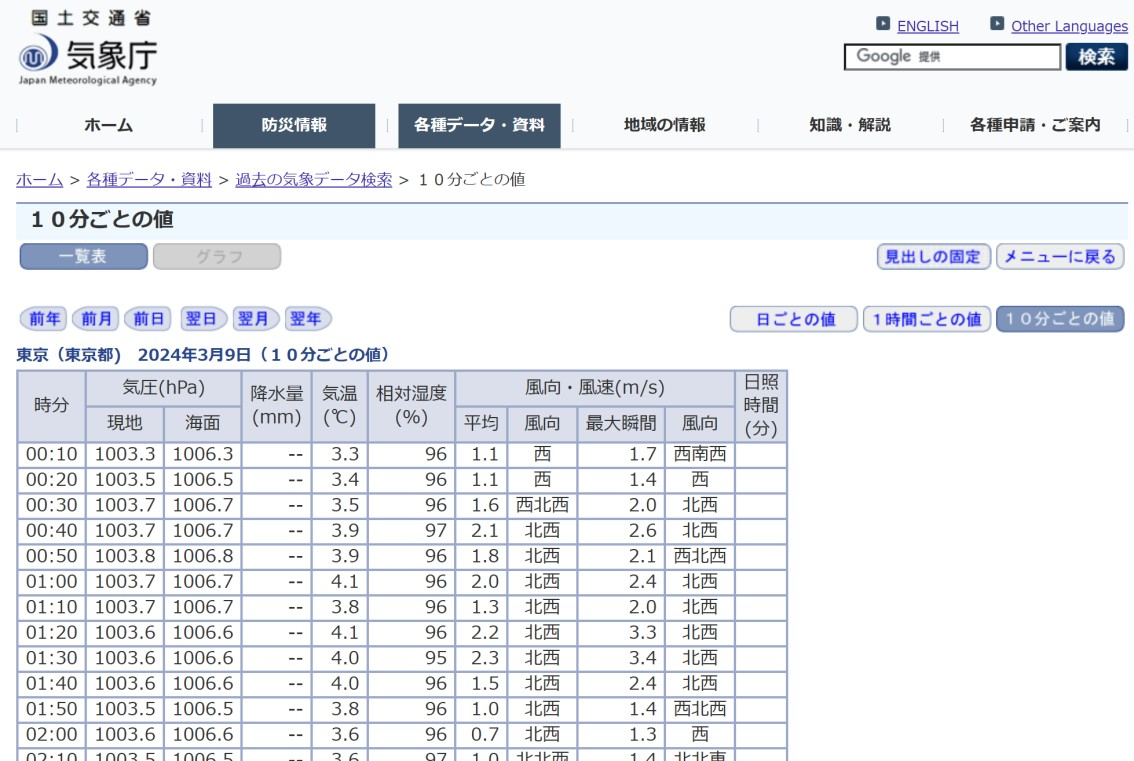{#fig-10min}

### Step 2: Data Scraping with the `requests` Library {#step-2}

Next, we'd like to scrape all the HTML from the webpage. We'll need to import the `requests` library to do the scraping.

In [14]:
# Library required for data scraping
import requests

The `requests.get()` function inside this library can send an HTTP GET request to the designated URL:

In [15]:
# HTTP GET request to testURL
# Execute care to avoid running multiple requests in a very short period of time
step2_resp = requests.get(testURL)

This returns a `Response` object, a class defined by the `requests` library, that stores the server's reply when accessing the designated URL. The `Response` object has many attributes, including its content.

In [16]:
print("Returned object type:\n\t", type(step2_resp))

# Properties of Response object
step2_prop = step2_resp.__dict__.keys()
print("\nProperties and attributes in object:")
for prop_now in step2_prop:
    print('\t', prop_now)

Returned object type:
	 <class 'requests.models.Response'>

Properties and attributes in object:
	 _content
	 _content_consumed
	 _next
	 status_code
	 headers
	 raw
	 url
	 encoding
	 history
	 reason
	 cookies
	 elapsed
	 request
	 connection


Some of the other `Response` object attributes are useful for other applications, such as error handling. For now, we'll ignore these use cases and parse the HTML content using `Beautiful Soup`.

### Step 3: Initial HTML Parsing with `Beautiful Soup`

With the response in hand, we can now parse the raw HTML. Import the `BeautifulSoup()` function from `bs4`:

In [17]:
# Import the BeautifulSoup function from bs4 library
from bs4 import BeautifulSoup

Much like how humans understand a sequence of words only when the sequence follows a set of known grammatical rules, a computer program needs to know what to expect to make sense of the raw data. In other words, when a program "reads" HTML, it needs an HTML parser to understand and process it.

We'll use Python's built-in HTML parser, `html.parser` to make sense of the contents of the `Response` object from step 2. This will return a `BeautifulSoup` object.

In [18]:
# HTML parser to make sense of the Response object
step3_soup = BeautifulSoup(step2_resp.content, "html.parser")
print("Returned object type:\n\t", type(step3_soup))

Returned object type:
	 <class 'bs4.BeautifulSoup'>


After parsing HTML with `BeautifulSoup`, we can safely navigate the contents. Namely, HTML consists of tags that define specific sections within the content. Most elements follow the pattern:

```
<tag_name> ...content... </tag_name>
```

Tags are often nested in a form of hierarchy. For example, every webpage can be broadly divided into two major sections, each with subsections:

- `<head>` contains metadata, scripts, page title
- `<body>` contains the visible content, including the tabular data

Let us print just the `<head>` section to see what structured HTML looks like:


In [19]:
print(step3_soup.head.prettify())

<head>
 <meta charset="utf-8"/>
 <title>
  気象庁｜過去の気象データ検索
 </title>
 <meta content="気象庁 Japan Meteorological Agency" name="Author"/>
 <meta content="気象庁 Japan Meteorological Agency" name="keywords"/>
 <meta content="気象庁｜過去の気象データ検索" name="description"/>
 <meta content="text/css" http-equiv="Content-Style-Type"/>
 <meta content="text/javascript" http-equiv="Content-Script-Type"/>
 <link href="/com/css/define.css" media="all" rel="stylesheet" type="text/css"/>
 <link href="../../css/default.css" media="all" rel="stylesheet" type="text/css"/>
 <script language="JavaScript" src="/com/js/jquery.js" type="text/JavaScript">
 </script>
 <script language="JavaScript" src="../js/jquery.tablefix.js" type="text/JavaScript">
 </script>
 <style media="all" type="text/css">
  <!-- @import url(/com/default.css); -->
 </style>
 <link href="../../data/css/kako.css" media="all" rel="stylesheet" type="text/css"/>
 <link href="../../data/css/print.css" media="print" rel="stylesheet" type="text/css"/>
</head

The nested hierarchy structure can be easily spotted in the first lines:

```
<head>
  ...
  <title>
  気象庁｜過去の気象データ検索
  </title>
  ...
</head>
```

In a similar manner, the tabular data to extract is contained within `<body> ...tabular data... </body>`.

### Step 4: Navigate the HTML and Extract the Desired Table

Unfortunately, the HTML body contains much more than the tabular data. If you are curious as to just how much content is inside the HTML body, try running the following code on your own:

```
print(step3_soup.body)
```

You can scroll through the whole HTML and manually search out the tags containing the tabular data. However, I will show you two slightly more sophisticated 🧐 search methods. One approach locates the desired table using a manual top-down method, and the other uses an automated bottom-up method.

#### Step 4-A: Top-Down Approach to Locating the Desired Table
With the top-down approach to locating the desired table, you will need to manually access the URL you are scraping data from. Right-click and select "Inspect"

#### Step 4-B: Bottom-Up Approach to Locating the Desired Table
The bottom-up approach to locating the desired table takes advantage of the following: 

- Target data is likely within `<table> ... </table>` tags
- Target data contains `'00:10'` as a data element as seen in @fig-10min

The `BeautifulSoup.find_all()` method can search for all `<table>` tags, and pinpoint the table containing `'00:10'` as a string.

In [20]:
# Find all the <table> tags
step4_tables = step3_soup.body.find_all('table')

print("Total number of <table> tags:\t", len(step4_tables), '\n')

# Search for '00:10' string in the table
for table in step4_tables:
    print(table.attrs) # Print attributes of the table

    # If the '00:10' string is inside this table
    if table.find_all(string='00:10') != []:
        print('\tFound the target table:')
        # If the table contains the '00:10' string, print out the first five rows
        table_contents = table.find_all('tr')
        for i in range(3):
            print('\t\t', table_contents[i])

Total number of <table> tags:	 6 

{'style': 'float:left'}
{'style': 'margin-left: auto'}
{'style': 'float:left;margin-top: 25px'}
{'style': 'margin-left: auto;margin-top: 25px'}
{'id': 'tablefix1', 'class': ['data2_s']}
	Found the target table:
		 <tr class="mtx"><th rowspan="2" scope="col">時分</th><th colspan="2" scope="colgroup">気圧(hPa)</th><th rowspan="2" scope="col">降水量<br/>(mm)</th><th rowspan="2" scope="col">気温<br/>(℃)</th><th rowspan="2" scope="col">相対湿度<br/>(％)</th><th colspan="4" scope="colgroup">風向・風速(m/s)</th><th rowspan="2" scope="col">日照<br/>時間<br/>(分)</th></tr>
		 <tr class="mtx" scope="col"><th scope="col">現地</th><th scope="col">海面</th><th scope="col">平均</th><th scope="col">風向</th><th scope="col">最大瞬間</th><th scope="col">風向</th></tr>
		 <tr class="mtx" style="text-align:right;"><td style="white-space:nowrap">00:10</td><td class="data_0_0">1003.3</td><td class="data_0_0">1006.3</td><td class="data_0_0">--</td><td class="data_0_0">3.3</td><td class="data_0_0">96</td><td cl

By selectively searching for the `'00:10'` string nested inside `<table>` tags, we have quickly isolated the meteorological data buried inside the long HTML `<body>`. The contents within the first few table rows (as specificed by `<tr>` tags) confirm that the desired data is, indeed, in this table.

The printed out table attributes indicate that the desired table has:

- ID of `tablefix1`
- class of `data2_s`

We can now select the one desired table by specifying either `#id` or `.class` in the `soup.select()` method:

In [21]:
# Select the target table with either code below
step4_targetTable = step3_soup.select('table.data2_s')
#step4_targetTable = step3_soup.select('table#tablefix1') # Alternative method

print("Number of tables selected:\t", len(step4_targetTable))

Number of tables selected:	 1


However, for the tabular data to be useful in data analysis projects, HTML format is not ideal. We will work through the table row-by-row, cell-by-cell to migrate data from the HTML format to a `pandas` DataFrame.

To process the table row-by-row, re-write the `soup.select()` function to find the `<tr>`, or table row tag elements, within `<table class=data2_s>`:

In [22]:
# Select all rows within the target table
step4_tableRows = step3_soup.select('table.data2_s tr')

This provides us with an object with 146 separate table rows. Inspecting the first few confirms we've successfully isolated the data we need.

<a name="step4_tableRows"></a>

In [23]:
print("Number of rows in table:\t", len(step4_tableRows))

# Print out the first couple table rows
for i in range(3):
    print('\t', step4_tableRows[i])

Number of rows in table:	 146
	 <tr class="mtx"><th rowspan="2" scope="col">時分</th><th colspan="2" scope="colgroup">気圧(hPa)</th><th rowspan="2" scope="col">降水量<br/>(mm)</th><th rowspan="2" scope="col">気温<br/>(℃)</th><th rowspan="2" scope="col">相対湿度<br/>(％)</th><th colspan="4" scope="colgroup">風向・風速(m/s)</th><th rowspan="2" scope="col">日照<br/>時間<br/>(分)</th></tr>
	 <tr class="mtx" scope="col"><th scope="col">現地</th><th scope="col">海面</th><th scope="col">平均</th><th scope="col">風向</th><th scope="col">最大瞬間</th><th scope="col">風向</th></tr>
	 <tr class="mtx" style="text-align:right;"><td style="white-space:nowrap">00:10</td><td class="data_0_0">1003.3</td><td class="data_0_0">1006.3</td><td class="data_0_0">--</td><td class="data_0_0">3.3</td><td class="data_0_0">96</td><td class="data_0_0">1.1</td><td class="data_0_0" style="text-align:center">西</td><td class="data_0_0">1.7</td><td class="data_0_0" style="text-align:center">西南西</td><td class="data_0_0"></td></tr>


Note that the first two rows in the table are column headers. The actual data starts on row 3. Additionally, the wind direction data is recorded as Japanese kanji characters. We'd like to convert these into English in a `pandas` DataFrame with the next step.

### Step 5: Create a DataFrame with the Fully Parsed Data Using `for` Loops

From the isolated table rows, we extract the weather data and place them into a structured `pandas` DataFrame using a `for` loop to work through each row.

First, import the `pandas` library.

In [24]:
import pandas as pd

Then, create an empty DataFrame. I've provided the English translation of the column headers below:

In [25]:
# The Tokyo observation site (type s1) has 11 columns of data
headers_s1 = (['time',
               'local atmospheric pressure (hPa)',
               'sea level pressure (hPa)',
               'precipitation (mm)',
               'temperature (℃)',
               'relative humidity',
               'average wind speed (m/s)',
               'average wind direction',
               'max wind speed (m/s)',
               'max wind direction',
               'sunshine (minutes)'])

# If you are using a 'a1' type observation site, use the headers below
headers_a1 = (['time',
               'precipitation (mm)',
               'temperature (℃)',
               'relative humidity',
               'average wind speed (m/s)',
               'average wind direction',
               'max wind speed (m/s)',
               'max wind direction',
               'sunshine (minutes)'])

# Specify the header you'll be using
headers_now = headers_s1 # Change to headers_a1 if using 'a1' type observation site

# Empty dataframe to fill with data
step5_df = pd.DataFrame(columns=headers_now)

Referring back to the [sample table rows](#step4_tableRows) from the previous step, a few things stand out:

1. The first two table rows contain **no data**, only headers
2. Every data row begins with a `<td>` or table data tag containing the **time** in `'HH:MM'` format
3. All remaining meteorological values appear inside `<td class="data_0_0">` elements.

We can use these patterns to guide our parsing when working row-by-row in the `for` loop. Start by skipping the header information.


#### Step 5-1: Skip Rows Corresponding to Column Headers

We'll filter out the rows containing just the column headers. These are characterized by rows that do not contain any `data_0_0` class data. As such, the method call of `soup.select('td.data_0_0')` will return an empty list. This will safely skip the column headers table rows, regardless of the number of rows the original table contains.

In [26]:
# Iterate through each row in the table
for rowNow in step4_tableRows:

  # Search for the data_0_0 class (actual weather data)
  list_data = rowNow.select('td.data_0_0')

  if len(list_data) == 0:
    # There is no data in this row (ie. column headers), so skip
    print("Skipping row: ", rowNow)
    continue

Skipping row:  <tr class="mtx"><th rowspan="2" scope="col">時分</th><th colspan="2" scope="colgroup">気圧(hPa)</th><th rowspan="2" scope="col">降水量<br/>(mm)</th><th rowspan="2" scope="col">気温<br/>(℃)</th><th rowspan="2" scope="col">相対湿度<br/>(％)</th><th colspan="4" scope="colgroup">風向・風速(m/s)</th><th rowspan="2" scope="col">日照<br/>時間<br/>(分)</th></tr>
Skipping row:  <tr class="mtx" scope="col"><th scope="col">現地</th><th scope="col">海面</th><th scope="col">平均</th><th scope="col">風向</th><th scope="col">最大瞬間</th><th scope="col">風向</th></tr>


Once the column headers are skipped, we'd like to extract the first data element in the row.

#### Step 5-2: Extract the Timestamps

After skipping the rows with no data, we'll extract the first data, which are timestamps when the weather data were collected. Since the first `<td>` tag in each valid row always contains the timestamp, we can

- Use `soup.select_one('td')` to pull out just the first element
- Clean the timestamp string with `.text.strip()`
    - Remove HTML tags with `.text()`
    - Remove extra spaces with `.strip()`
- Assign it to the first column of the DataFrame using `df.loc[]` attribute

Let's add this code to the `for` loop from before:

In [27]:
# Iterate through each row in the table
rowCount = 0
for rowNow in step4_tableRows:

  # Search for the data_0_0 class that contains the weather data
  list_data = rowNow.select('.data_0_0')

  if len(list_data) == 0:
    # There is no data in this row (ie. it is a column headers), so skip
    #print("Skipping row: ", rowNow)
    continue

  else:
    # Extract time
    time1 = rowNow.select_one('td') # Select just the first <td> tag element
    time2 = time1.text.strip()      # Remove the tags with .text(). Remove extra spaces with strip()
    #print(time2)

    # Assign the time to the first column in the DataFrame
    step5_df.loc[rowCount, headers_now[0]] = time2

    # Increment rowCount
    rowCount = rowCount + 1

You can verify that all timestamps from `'00:10'` to `'24:00'` have been assigned to the DataFrame by inspecting the first and last time entries:

In [28]:
print("First few lines:")
print(step5_df['time'].head())
print("\nLast few lines:")
print(step5_df['time'].tail())

First few lines:
0    00:10
1    00:20
2    00:30
3    00:40
4    00:50
Name: time, dtype: object

Last few lines:
139    23:20
140    23:30
141    23:40
142    23:50
143    24:00
Name: time, dtype: object


The column headers are omitted, and the first data element, the timestamps, have been successfully transferred from HTML to a `pandas` DataFrame. All that remains is to migrate the weather data.

#### Step 5-3: Retrieve the Meteorological Data

The loop can skip the column headers and collect the time information, so now we'd like to extract the remaining meteorological data from the `data_0_0` class elements. To do so, we'll use a nested `for` loop that looks for `<td class="data_0_0">` data element, clean the string, and insert it into the DataFrame.

However, the keen-eyed reader would have noticed that the wind direction data is recorded as Japanese kanji. We will translate these into English compass notation (NESW notation) within the `for` loop.

I've provided you with the [`ConvertKanji2NESW()` function](#ConvertKanji2NESW) that translates the Japanese kanji into English compass notation:

<a name='ConvertKanji2NESW'></a>

In [29]:
def ConvertKanji2NESW(kanji_windDir):
    """Function to convert the wind direction from kanji to English
    AUTHOR:     Mai Tanaka (www.DataDrivenMai.com)
    DATE:       2026-03-31
    REQUIRES:   kanji_windDir = Full kanji indicating wind direction (eg. '北東')
    RETURNS:    english_windDir = Wind direction in English in N/E/S/W notation (eg. 'NE')
    """
    # Start with an empty string
    english_windDir = ''

    # Handle the special case: 静穏 (tranquil or no wind)
    if kanji_windDir == '静穏':
        english_windDir = 'tranquil'
        return english_windDir

    # Kanji to character (NESW) conversion, character-by-character
    for kanji_char in kanji_windDir:
        if kanji_char == '北':
            english_windDir = english_windDir + 'N'
        if kanji_char == '東':
            english_windDir = english_windDir + 'E'
        if kanji_char == '南':
            english_windDir = english_windDir + 'S'
        if kanji_char == '西':
            english_windDir = english_windDir + 'W'

    # Return English wind direction
    return english_windDir

Working through the tabular data cell-by-cell, each weather data element is cleaned using `.text()` and `.strip()` to remove the HTML tags and spaces, respectively. If the data element corresponds to 'wind direction', we apply the `ConvertKanji2NESW()` function above. The cleaned data can finally be placed in the `pandas` DataFrame under the appropriate header using `df.loc[]`.

In [30]:
# Iterate through each row in the table
rowCount = 0
for rowNow in step4_tableRows:

  # Search for the data_0_0 class
  list_data = rowNow.select('.data_0_0')

  if len(list_data) == 0:
    # There is no data in this row, so skip
    #print("Skipping row: ", rowNow)
    continue

  else:
    # Extract time
    time1 = rowNow.select_one('td') # Select just the first <td> tag element
    time2 = time1.text.strip()      # Remove the tags with .text(). Remove extra spaces with strip()
    #print(time2)

    # Assign the time to the DataFrame
    step5_df.loc[rowCount, headers_now[0]] = time2

    # Work through each data element to extract meteorological data
    columnCount = 1
    for dataNow in list_data:
      # Extract just the data (remove tags and spaces)
      justData = dataNow.text.strip()

      # If the data type is wind direction, convert from Kanji to alphabet
      if "wind direction" in headers_now[columnCount]:
        justData = ConvertKanji2NESW(justData)

      # Save the data into the appropriate location and increment columnCount
      step5_df.loc[rowCount, headers_now[columnCount]] = justData
      columnCount = columnCount + 1

    # Increment the rowCount
    rowCount = rowCount + 1

A quick check of the first few lines in the resulting DataFrame confirms that all data values of time, atmospheric pressure, temperature, humidity, wind speed and others, have been successfully extracted. Furthermore, wind direction has been converted from Japanese kanji to English.

In [31]:
step5_df.head()

,time,local atmospheric pressure (hPa),sea level pressure (hPa),precipitation (mm),temperature (℃),relative humidity,average wind speed (m/s),average wind direction,max wind speed (m/s),max wind direction,sunshine (minutes)
0,00:10,1003.3,1006.3,--,3.3,96,1.1,W,1.7,WSW,
1,00:20,1003.5,1006.5,--,3.4,96,1.1,W,1.4,W,
2,00:30,1003.7,1006.7,--,3.5,96,1.6,WNW,2.0,NW,
3,00:40,1003.7,1006.7,--,3.9,97,2.1,NW,2.6,NW,
4,00:50,1003.8,1006.8,--,3.9,96,1.8,NW,2.1,WNW,


The final step is to save the `pandas` DataFrame as a CSV for use in subsequent data analysis projects. 

### **Tip 3: Timestamps as `datetime` objects**

In the DataFrame we created in Method 2, the 'time' column contained values like "00:50" — but these are stored as strings, not as actual time-aware objects.

In [ ]:
pickedTime = method2_steps4_5_df.loc[4, 'time']
pTime_type = type(pickedTime)
print(pickedTime, "\ttype: ", pTime_type)

While humans immediately recognize "00:50" as a timestamp, Python treats it simply as text. This means:
- You cannot sort chronologically,
- You cannot perform time arithmetic (e.g., “+10 minutes”),

More importantly, the timestamp does not indicate the date, which can lead to confusion when processing multiple days.

To work with timestamps properly, it's best to convert them into Python's datetime objects.

First, import the module:

In [ ]:
import datetime as dt

A datetime object explicitly stores year, month, day, hour, and minute, making it both machine-readable and unambiguous to humans. Here's how to create one manually:

In [ ]:
pickedTime_dt = dt.datetime(2024, 3, 9, 0, 50)# March 9, 2024, 0:50
pTime_dt_type = type(pickedTime_dt)
print(pickedTime_dt, "\ttype: ", pTime_dt_type)

We can apply the same idea of converting the time string into a datetime object inside our row-by-row parsing workflow from Method 2. This is especially useful because the HTML table only provides the time (e.g., "00:50"), not the full date.

To recreate the complete timestamp, we use:
- A known date (provided as a tuple like (2024, 3, 9)), and
- The time extracted from the first `<td>` element in each row

Python's `datetime.strptime()` makes it easy to convert strings such as '00:50' into usable hour-and-minute values.

Below is the updated parsing loop with datetime handling added:

In [ ]:
# test date
test_date = (2024, 3, 9)

# Create an empty DataFrame with the designated headers
tipsTricks3_df = pd.DataFrame(columns=headers_s1)

# Iterate through each row in the table
rowCount = 0
for rowNow in method2_step3_tableRows:

  # Search for the data_0_0 class
  list_data = rowNow.select('.data_0_0')

  if len(list_data) == 0:
    # There is no data in this row, so skip
    #print("Skipping row: ", rowNow)
    continue

  else:
    # Convert time from string to datetime object
    # Split up target_date tuple into year, month and day
    target_year = test_date[0]
    target_month = test_date[1]
    target_day = test_date[2]

    # Timestamp is the first td element in the row
    temptime = rowNow.select_one('td')

    # Strip away the tags and excess spaces
    temptime = temptime.text.strip()

    # The last timestamp may be 0:00 for the next day, which may cross over into next month or even year
    if (temptime == '24:00'):
      # Set output_datetime as 23:59 of the current day, then add one minute.
      # This should deal with changes in the day, month or even the year
      deltaTime = dt.timedelta(minutes=1)
      dateTimeNow = dt.datetime(target_year, target_month, target_day, 23, 59) + deltaTime

    else:
      # Otherwise, extract the hour and minutes and use that as the hour and minute
      temptime = dt.datetime.strptime(temptime, '%H:%M')
      dateTimeNow = dt.datetime(target_year, target_month, target_day, temptime.hour, temptime.minute)

    # Assign the extracted datetime object to the dataframe
    tipsTricks3_df.loc[rowCount, headers_s1[0]] = dateTimeNow

    # Work through each data element to extract meteorological data
    columnCount = 1
    for dataNow in list_data:
      # Extract just the data (remove tags and spaces)
      justData = dataNow.text.strip()

      # If the data type is wind direction, convert from Kanji to alphabet
      if "wind direction" in headers_s1[columnCount]:
        justData = ConvertKanji2NESW(justData)

      # Save the data into the appropriate location and increment columnCount
      tipsTricks3_df.loc[rowCount, headers_s1[columnCount]] = justData
      columnCount = columnCount + 1

    # Increment the rowCount
    rowCount = rowCount + 1

Once converted, Python instantly understands that this represents a point in time — enabling powerful operations such as adding timezone information (coming next!), resampling, shifting, or merging with other time-indexed datasets.

### **Tip 4: Attributing Time Zones to datetime Objects**

The datetime object created in the previous tip is almost complete, but not quite. To properly work with time-series data, especially when combining information from multiple sources, it mayh be beneficial to attach a time zone.

This is important because datasets often use different standards. For example:
- JMA meteorological data is recorded in Japan Standard Time (JST)
- Many other datasets, especially those from APIs, are recorded in UTC (Coordinated Universal Time)

If you try to combine these without explicit time zone information, you'll quickly run into alignment problems, shifting timestamps, and subtle bugs.

To work with time zones in Python, we'll use the pytz library.

In [ ]:
import pytz

Then, use `pytz.timezone()` to specify the correct time zone for the data:

In [ ]:
JMA_tz = pytz.timezone('Asia/Tokyo') # Create a time zone in Japan time

Now you can attach this time zone to a datetime object using the `localize()` method:

In [ ]:
pickedTime_dt_tz = JMA_tz.localize(dt.datetime(2024, 3, 9, 0, 50)) # 0:50 on March 9, 2024

pTime_dt_tz_type = type(pickedTime_dt_tz)
print(pickedTime_dt_tz, "\ttype: ", pTime_dt_tz_type) # datetime object now has a time zone

You'll notice a `+09:00` appended to the timestamp. This indicates that Japan is nine hours ahead of Coordinated Universal Time (UTC).

We can now apply this idea to the timestamps extracted from the HTML table.

Instead of handling time parsing inside the main scraping loop (as we did earlier), we'll make our code cleaner and modular by creating a helper function, `ConvertDateTime()`.

This function:
- takes a row of HTML
- extracts the timestamp (e.g., "00:50")
- converts it into a datetime object using the desired date
- attaches the correct time zone
- handles special cases like "24:00" (which belongs to the next day)


In [ ]:
# Function to take in a row of data, extract the time stamp, convert it to a datetime object in a local time zone
# REQUIRES: row_of_data = html where the first <td> cell contains the time in the form of %H:%M
#           target_tz = target timezone as an pytz.timezone object
#           target_date = year, month and day to assign to the datetime object
# PROMISES: returns output_datetime, a datetime object in the specified local timezone

def ConvertDateTime(row_of_data, target_tz, target_date):

  # Split up target_date tuple into year, month and day
  target_year = target_date[0]
  target_month = target_date[1]
  target_day = target_date[2]

  # Timestamp is the first td element in the row
  temptime = row_of_data.select_one('td')

  # Strip away the tags and excess spaces
  temptime = temptime.text.strip()

  # The last timestamp may be 0:00 for the next day, which may cross over into next month or even year
  if (temptime == '24:00'):
    # Set output_datetime as 23:59 of the current day, then add one minute.
    # This should deal with changes in the day, month or even the year
    deltaTime = dt.timedelta(minutes=1)
    tempDateTime = dt.datetime(target_year, target_month, target_day, 23, 59) + deltaTime

  else:
    # Otherwise, extract the hour and minutes and use that as the hour and minute
    temptime = dt.datetime.strptime(temptime, '%H:%M')
    tempDateTime = dt.datetime(target_year, target_month, target_day, temptime.hour, temptime.minute)

  # Attach a time zone
  output_datetime = JMA_tz.localize(tempDateTime)

  # Return the datetime
  return output_datetime

Now we can reuse the scraping loop from Method 2, but with a cleaner structure. Instead of manually parsing timestamps inside the loop, we call the conversion function.

In [ ]:
# Create an empty DataFrame with the designated headers
tipsTricks4_df = pd.DataFrame(columns=headers_s1)

# Iterate through each row in the table
rowCount = 0
for rowNow in method2_step3_tableRows:

  # Search for the data_0_0 class
  list_data = rowNow.select('.data_0_0')

  if len(list_data) == 0:
    # There is no data in this row, so skip
    #print("Skipping row: ", rowNow)
    continue

  else:
    # Convert time from string to datetime with time zone and assign it
    time3 = ConvertDateTime(rowNow, JMA_tz, (2024, 3, 9))
    tipsTricks4_df.loc[rowCount, headers_s1[0]] = time3

    # Work through each data element to extract meteorological data
    columnCount = 1
    for dataNow in list_data:
      # Extract just the data (remove tags and spaces)
      justData = dataNow.text.strip()

      # If the data type is wind direction, convert from Kanji to alphabet
      if "wind direction" in headers_s1[columnCount]:
        justData = ConvertKanji2NESW(justData)

      # Save the data into the appropriate location and increment columnCount
      tipsTricks4_df.loc[rowCount, headers_s1[columnCount]] = justData
      columnCount = columnCount + 1

    # Increment the rowCount
    rowCount = rowCount + 1

Your final DataFrame now contains time-zone-aware timestamps in the first column:

In [ ]:
pickedTime_loop = tipsTricks4_df.loc[4, 'time']
pTime_loop_type = type(pickedTime_loop)
print(pickedTime_loop, "\ttype: ", pTime_loop_type)

These timestamps now carry proper time zone metadata, ensuring that downstream analysis (plotting, merging, resampling, aligning time series, etc.) is accurate and consistent.

### Step 6: Save DataFrame as a CSV File

In the final step, we save the fully populated and cleaned DataFrame as a CSV file. We can use `pandas`' built-in `pandas.to_csv()` method to write the data out. Just specify the desired file path (and make sure the directory exists in your local environment), disable the index column, and choose an appropriate text encoding (UTF-8 is a safe default).

In [ ]:
# Specify a strong filename in a directory that exists
fileName = 'jma_weather_scraping_jupyter.csv'
dirName = 'SampleData_JMA/'
savefileName = dirName + fileName
step5_df.to_csv(savefileName, index=False, encoding='utf-8')

This saves a CSV file with the scraped and parsed weather data that you can access any time.

### **Tip 5: Save and Load Tables with `datetime`**

Now that we've attached time zones to our timestamps, the next challenge is making sure those datetime objects survive when saving to, and loading from, a CSV file.

Saving is the easy part. Just write out the DataFrame as usual using `df.to_csv()`:

In [ ]:
savefile_tipsTricks5 = dirName + 'test_tipsTricks2.csv'
tipsTricks4_df.to_csv(savefile_tipsTricks5, index=False, encoding='utf-8')

However, when you load this file back in with a plain `pd.read_csv()`, the date column will contain data that looks like datetime objects, but are actually just strings:

In [ ]:
tipsTricks5_load1 = pd.read_csv(savefile_tipsTricks5) # Simple load

pickedTime_load1 = tipsTricks5_load1.loc[4, 'time']
pTime_load1_type = type(pickedTime_load1)
print(pickedTime_load1, "\ttype: ", pTime_load1_type)

To ensure pandas correctly interprets the date column as datetime objects, include the `parse_dates` argument when reading the file. In most cases, simply listing the column name is enough:

In [ ]:
tipsTricks5_load2 = pd.read_csv(savefile_tipsTricks5, parse_dates=['time'])

pickedTime_load2 = tipsTricks5_load2.loc[4, 'time']
pTime_load2_type = type(pickedTime_load2)
print(pickedTime_load2, "\ttype: ", pTime_load2_type)

If you've already loaded the CSV without parsing the time column, you can still convert it afterward using `pd.to_datetime()`:

In [ ]:
tipsTricks5_alt = pd.to_datetime(tipsTricks5_load1['time']) # Convert strings from the first pd.read_csv function call into datetime objects

pickedTime_alt = tipsTricks5_alt.loc[4]
pTime_alt_type = type(pickedTime_alt)
print(pickedTime_alt, "\ttype: ", pTime_alt_type)

And that's it!

You now know how to store datetime objects (including time zone aware ones) and reliably load them back into pandas without losing crucial timestamp information.

## Summary

Congratulations! 

You now have a full toolkit for scraping and parsing structured data from the JMA website using a combination of the `requests`, `Beautiful Soup`, and `pandas` libraries. A quick summary of the steps we took:

1. Designated the URL to access data from
2. Accessed the URL using `requests.get()` and obtained the raw HTML
3. Parsed the raw HTML using `BeautifulSoup()`
4. Navigated the complex HTML structure and isolated the target table using `soup.select()`
5. Manually parsed each table row whilst
  - Skipping rows with no data
  - Extracting and cleaning the timestamps
  - Pulling out meteorological data and assigning them to the correct DataFrame columns
    - Translating the wind direction from Japanese kanji to English
6. Exported the fully parsed DataFrame to a CSV file using `df.to_csv()`

For more tips, tricks and tutorials, be sure to check out the blog posts in the Further Readings.

Happy data scraping!

## References

1. Japan Meteorological Agency. 地域気象観測システム（アメダス）. 気象庁 https://www.jma.go.jp/jma/kishou/know/amedas/kaisetsu.html.
